# Assignment 12

Please fill in blanks in the *Answer* sections of this notebook. To check your answer for a problem, run the Setup, Answer, and Result sections. DO NOT MODIFY SETUP OR RESULT CELLS. See the [README](https://github.com/mortonne/datascipsych) for instructions on setting up a Python environment to run this notebook.

Write your answers for each problem. Then restart the kernel, run all cells, and then save the notebook. Upload your notebook to Canvas.

If you get stuck, read through the other notebooks in this directory, ask us for help in class, or ask other students for help in class or on the weekly discussion board.

## Problem: comparing two conditions (6 points)

Given the recognition memory dataset (defined below) in `data`, test whether there is a difference in response between targets and lures. 

The code below carries out the first step of this analysis, by calculating the mean for each subject and trial type. Those means are stored in the `mean_trial_type` DataFrame below.

The sub-problems go through the remaining steps of visualizing the data in each condition, calculating summary statistics, and running a t-test to test for a significant effect of trial type. Finally, the last sub-problem involves writing text to describe the results of your analysis. See the sub-problems below for directions.

### Setup

In [45]:
import polars as pl
import seaborn as sns
import pingouin as pg
import pandas as pd
from IPython.display import display
data = pl.read_csv("gen_recog2.csv")
mean_trial_type = (
    data.group_by("subject", "trial_type")
    .agg(pl.col("response").mean())
    .sort("subject", "trial_type")
)
g1 = None
stats_trial_type = None
ttest_trial_type = None
mean_trial_type.head()

subject,trial_type,response
str,str,f64
"""subj01""","""lure""",0.35
"""subj01""","""target""",0.566667
"""subj02""","""lure""",0.333333
"""subj02""","""target""",0.566667
"""subj03""","""lure""",0.3


### Answer

#### Visualize means in each condition (2 points)

Use the `mean_trial_type` DataFrame to make a bar plot with error bars showing the mean response for targets and lures (1 point). Trial type (targets and lures) should be on the x-axis, and response should be on the y-axis. Assign the output from Seaborn to a variable called `g1`.

Write a caption in a Markdown cell under the plot (1 point). See the [Reporting](https://mortonne.github.io/datascipsych/assignments/assignment12/reporting.html) lecture for example captions.

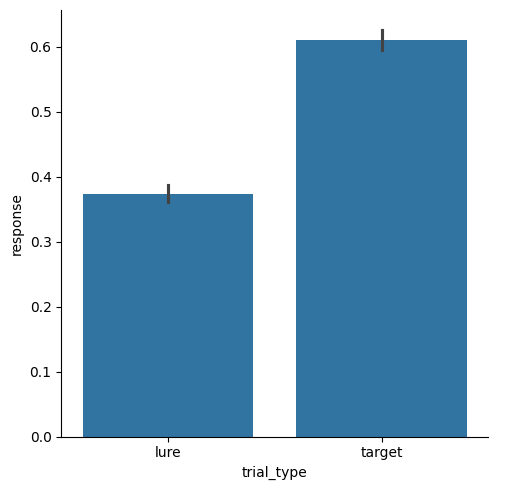

In [46]:
stats_trial_type = (mean_trial_type)
stats_trial_type_pd = stats_trial_type.to_pandas()

g1 = sns.catplot(
    data=stats_trial_type_pd,
    x="trial_type",
    y="response",
    kind= 'bar',
    errorbar="se",  
)

if g1 is not None:
    print(g1)

> Write a caption for your figure. Explain what variables are shown and what the error bars represent.

Figure 1. Mean response for each trial type: lure (M = 0.37) and target (M = 0.60). Bars show the average response across participants, with higher values indicating stronger recognition memory. Error bars represent the standard error of the mean (SEM), capturing variability across subjects. Participants responded more strongly to targets than to lures, suggesting successful discrimination between old and new items.

#### Calculate summary statistics (1 point)

Use the `mean_trial_type` DataFrame to calculate the mean and SEM for the responses in the target and lure conditions. In the DataFrame with the statistics, there should be two columns named `mean` and `sem`. Assign the output to a variable called `stats_trial_type`.

In [62]:
stats_trial_type = (
    mean_trial_type
    .group_by("trial_type")
    .agg([
        pl.col("response").mean().alias("mean"),
        (pl.col("response").std(ddof=1) / pl.col("response").len().sqrt()).alias("sem") 
    ])
)

if stats_trial_type is not None:
    display(stats_trial_type.sort("trial_type"))

trial_type,mean,sem
str,f64,f64
"""lure""",0.373889,0.013244
"""target""",0.610556,0.014875


#### Test for a significant difference (1 point)

Use the data in the `mean_trial_type` DataFrame to run a paired t-test to test whether there is a significant difference in response between the target and lure conditions. Assign the result to a variable called `ttest_trial_type`. Hint: you will need to make a pivoted DataFrame before running the t-test.

In [48]:
pivoted_df = (
    mean_trial_type
    .pivot(index="subject", on="trial_type", values="response")
)

ttest_trial_type = pg.ttest(
    pivoted_df["target"],
    pivoted_df["lure"],
    paired=True 
)

if ttest_trial_type is not None:
    display(ttest_trial_type)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,11.35405,29,two-sided,3.432506e-12,"[0.19, 0.28]",3.068197,2.461e+09,1.0


#### Report the results (2 points)

Write text describing the results of your analyses. Report the mean and SEM for each trial type (targets and lures) (0.5 points), the results of the t-test (1 point), and your conclusion about whether there is an effect of trial type on response (0.5 points). See the [Reporting](https://mortonne.github.io/datascipsych/assignments/assignment12/reporting.html) lecture for example text.

> Please describe your results below.

The mean response for the lure condition was 0.374 (SEM = 0.013), while for the target condition, it was 0.611 (SEM = 0.015). This suggests participants had a higher response to targets than to lures, indicating successful discrimination between the two types.

A paired t-test revealed a significant difference between the conditions, t(29) = 11.35, p < 0.001. The 95% confidence interval for the mean difference was between 0.19 and 0.28, with a large effect size (Cohen's d = 3.07).

The results show a statistically significant difference between target and lure responses, with a large effect size. This supports the conclusion that trial type (target vs. lure) significantly influences participants' responses.

In [49]:
print(stats_trial_type.columns)

['trial_type', 'mean', 'sem']


### Result

In [63]:
vars = [g1, stats_trial_type, ttest_trial_type]
if all([v is not None for v in vars]):
    # this should print your variables
    print(g1)
    stats_trial_type = stats_trial_type.sort("trial_type")
    display(stats_trial_type)
    display(ttest_trial_type)
    
    # this should not throw any errors
    assert isinstance(g1, sns.FacetGrid)
    assert stats_trial_type["mean"].round(3).equals(pl.Series([0.374, 0.611]))
    assert stats_trial_type["sem"].round(3).equals(pl.Series([0.013, 0.015]))
    assert round(ttest_trial_type.loc["T-test", "T"], 3) == 11.354
    assert ttest_trial_type.loc["T-test", "dof"] == 29
    assert ttest_trial_type.loc["T-test", "alternative"] == "two-sided"

trial_type,mean,sem
str,f64,f64
"""lure""",0.373889,0.013244
"""target""",0.610556,0.014875


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,11.35405,29,two-sided,3.432506e-12,"[0.19, 0.28]",3.068197,2.461e+09,1.0


## Problem: comparing three conditions (6 points)

Given the recognition memory dataset (defined below) in `data`, test whether there is responses for target trials depend on study time (1, 2, or 4 seconds).

The code below carries out the first step of this analysis, by calculating the mean response for target trials, for each subject and study time. Those means are stored in the `mean_study_time` DataFrame below.

The sub-problems go through the remaining steps of visualizing the data in each condition, calculating summary statistics, and running an ANOVA to test for a significant effect of study time. Finally, the last sub-problem involves writing text to describe the results of your analysis. See the sub-problems below for directions.

### Setup

In [82]:
mean_study_time = (
    data.filter(pl.col("trial_type") == "target")
    .group_by("subject", "study_time")
    .agg(pl.col("response").mean())
    .sort("subject", "study_time")
)
g2 = None
stats_study_time = None
anova_study_time = None
mean_study_time.head()

subject,study_time,response
str,i64,f64
"""subj01""",1,0.6
"""subj01""",2,0.5
"""subj01""",4,0.6
"""subj02""",1,0.55
"""subj02""",2,0.45


### Answer

#### Visualize means in each condition (2 points)

Use the `mean_study_time` DataFrame to make a line plot with error bands showing how the mean response varies with study time (1 point). The study time should be on the x-axis, and response should be on the y-axis. Assign the output from Seaborn to a variable called `g2`.

Write a caption in a Markdown cell under the plot (1 point). See the [Reporting](https://mortonne.github.io/datascipsych/assignments/assignment12/reporting.html) lecture for example captions.

Axes(0.125,0.11;0.775x0.77)


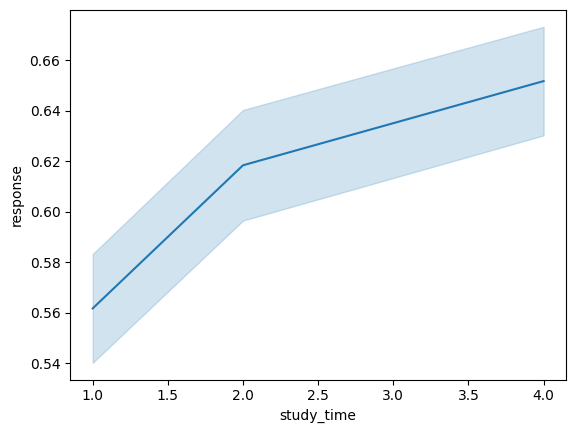

In [52]:
stats_study_time = (mean_study_time)
stats_study_time_pd = stats_study_time.sort("study_time").to_pandas()

g2 = sns.lineplot(
    data=stats_study_time_pd,
    x="study_time",
    y="response",
    errorbar="se",
)
if g2 is not None:
    print(g2)

> Write a caption for your figure. Explain what variables are shown and what the error bands represent.

*Figure 2.* This figure displays the mean response by study time. The x-axis shows study time levels (1, 2, and 4), and the y-axis shows the corresponding mean response values: approximately 0.56, 0.62, and 0.65, respectively. The shaded area around the line represents the standard error of the mean at each point, indicating the variability and reliability of these estimates. The positive trend suggests that as study time increases, so does the average response.

#### Calculate summary statistics (1 point)

Use the `mean_study_time` DataFrame to calculate the mean and SEM for the responses for different study times. In the DataFrame with the statistics, there should be two columns named `mean` and `sem`. Assign the output to a variable called `stats_study_time`.

In [53]:
stats_study_time = (
    mean_study_time
    .group_by("study_time")
    .agg([
        pl.col("response").mean().alias("mean"),
        (pl.col("response").std() / pl.col("response").count().sqrt()).alias("sem")
    ])
)
if stats_study_time is not None:
    display(stats_study_time.sort("study_time"))

study_time,mean,sem
i64,f64,f64
1,0.561667,0.021534
2,0.618333,0.021904
4,0.651667,0.021507


#### Test for a significant difference (1 point)

Use the data in the `mean_study_time` DataFrame to run a one-way repeated-measures ANOVA to test whether there is a significant difference in response depending on study time. Assign the result to a variable called `anova_study_time`. Hint: you will need to convert the DataFrame to Pandas format.

In [84]:
mean_study_time.head()

subject,study_time,response
str,i64,f64
"""subj01""",1,0.6
"""subj01""",2,0.5
"""subj01""",4,0.6
"""subj02""",1,0.55
"""subj02""",2,0.45


In [88]:
mean_study_time_pd = mean_study_time.to_pandas()
anova_study_time = pg.rm_anova(
    dv='response',
    within='study_time',
    subject='subject',
    data=mean_study_time_pd,
    detailed=True
)
# this should print out your variables
if anova_study_time is not None:
    display(anova_study_time)

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,study_time,0.124222,2,0.062111,5.578458,0.006084,0.092189,0.916193
1,Error,0.645778,58,0.011134,NaN,NaN,NaN,NaN


#### Report the results (2 points)

Write text describing the results. Report the mean and SEM for each study time (0.5 points), the results of the ANOVA (1 point), and your conclusion about whether there is an effect of study time on response (0.5 points). See the [Reporting](https://mortonne.github.io/datascipsych/assignments/assignment12/reporting.html) lecture for example text.

> Please describe your results below.

for study time, the mean was 0.5617 with an SEM of 0.0215. for study time 2, the mean was 0.6183 with an SEM of 0.0219, and for study time 4, the mean was 0.6517 with an SEM of 0.0215.

A repeated-measures ANOVA revealed a significant main effect of study time on the response variable, with an F-value of 5.58, a p-value of 0.0061, and an effect size (f2) of 0.092.

The analysis showed that study time had a significant effect on the response variable, with responses increasing as study time increased. The effect size (f2 = 0.092) indicates a small to moderate effect.

### Result

In [89]:
vars = [g2, stats_study_time, anova_study_time]
if all([v is not None for v in vars]):
    # this should print your variables
    print(g2)
    stats_study_time = stats_study_time.sort("study_time")
    display(stats_study_time)
    display(anova_study_time)
    
    # this should not throw any errors
    assert isinstance(g2, sns.FacetGrid)
    assert stats_study_time["mean"].round(3).equals(pl.Series([0.562, 0.618, 0.652]))
    assert stats_study_time["sem"].round(3).equals(pl.Series([0.022, 0.022, 0.022]))
    assert round(anova_study_time.loc[0, "F"], 3) == 5.578
    assert anova_study_time.loc[0, "ddof1"] == 2
    assert anova_study_time.loc[0, "ddof2"] == 58

## Problem (graduate students): testing for an interaction (8 points)

Given the recognition memory dataset (defined below) in `data`, test whether responses depend on study time (1, 2, or 4 seconds), trial type (target or lure), and an interaction between study time and trial type.

The sub-problems go through the steps of calculating means in each condition, visualizing the data in each condition, calculating summary statistics, and running a two-way repeated-measures ANOVA. Finally, the last sub-problem involves writing text to describe the results of your analysis. See the sub-problems below for directions.

### Setup

In [56]:
mean_st_tt = None
g3 = None
stats_st_tt = None
anova_st_tt = None
data.head()

subject,trial,study_time,item_type,trial_type,response
str,i64,i64,str,str,i64
"""subj01""",1,1,"""word""","""target""",1
"""subj01""",2,1,"""word""","""target""",1
"""subj01""",3,1,"""word""","""target""",1
"""subj01""",4,1,"""word""","""target""",1
"""subj01""",5,1,"""word""","""target""",1


### Answer

#### Calculate the mean for each subject in each condition (1 point)

Use the `data` DataFrame to calculate the mean response for each combination of subject, study time, and trial type. Assign your answer to a variable called `mean_st_tt`.

In [57]:
# your code here

# this should print your variables
if mean_st_tt is not None:
    display(mean_st_tt.sort("subject", "study_time", "trial_type"))

#### Visualize means in each condition (2 points)

Use the `mean_st_tt` DataFrame to make a line plot with error bands showing how the mean response (displayed on the y-axis) varies with study time (displayed on the x-axis) and trial type (displayed with different hues) (1 point). Assign the output from Seaborn to a variable called `g3`.

Write a caption in a Markdown cell under the plot (1 point).

In [58]:
# your code here

# this should print your variables
if g3 is not None:
    print(g3)

> Write a caption for your figure. Explain what variables are shown and what the error bands represent.

[answer here]

#### Calculate summary statistics (1 point)

Use the `mean_st_tt` DataFrame to calculate the mean and SEM for the responses for each combination of study time and trial type. In the DataFrame with the statistics, there should be two columns named `mean` and `sem`. Assign the output to a variable called `stats_st_tt`.

In [59]:
# your code here

# this should print your variables
if stats_st_tt is not None:
    display(stats_st_tt.sort("study_time", "trial_type"))

#### Test for a significant difference (1 point)

Use the data in the `mean_st_tt` DataFrame to run a two-way repeated-measures ANOVA to test whether there is a significant difference in response depending on study time, trial type, and/or an interaction between study time and trial type. Assign the result to a variable called `anova_st_tt`.

In [60]:
# your code here

# this should print out your variables
if anova_st_tt is not None:
    display(anova_st_tt)

#### Report the results (3 points)

Write text describing the results. Report the mean and SEM for each study time/trial type combination (0.5 points), the results of the ANOVA (1 point), and your conclusion about whether there is a main effect of study time, a main effect of trial type, and an interaction effect between study time and trial type (0.5 points for each effect). Report Greenhouse-Geisser corrected p-values. See the [Reporting](https://mortonne.github.io/datascipsych/assignments/assignment12/reporting.html) lecture for example text.

> Please describe your results below.

[answer here]

### Result

In [61]:
vars = [mean_st_tt, g3, stats_st_tt, anova_st_tt]
if all([v is not None for v in vars]):
    # this should print your variables
    mean_st_tt = mean_st_tt.sort("subject", "study_time", "trial_type")
    display(mean_st_tt)
    print(g3)
    stats_st_tt = stats_st_tt.sort("study_time", "trial_type")
    display(stats_st_tt)
    display(anova_st_tt)
    
    # this should not throw any errors
    assert isinstance(g3, sns.FacetGrid)
    assert stats_st_tt["mean"].round(3).equals(pl.Series([0.445, 0.562, 0.357, 0.618, 0.320, 0.652]))
    assert stats_st_tt["sem"].round(3).equals(pl.Series([0.023, 0.022, 0.020, 0.022, 0.020, 0.022]))
    assert round(anova_st_tt.loc[0, "F"], 3) == 0.488
    assert anova_st_tt.loc[0, "ddof1"] == 2
    assert anova_st_tt.loc[0, "ddof2"] == 58
    assert round(anova_st_tt.loc[1, "F"], 3) == 128.914
    assert anova_st_tt.loc[1, "ddof1"] == 1
    assert anova_st_tt.loc[1, "ddof2"] == 29
    assert round(anova_st_tt.loc[2, "F"], 3) == 15.574
    assert anova_st_tt.loc[2, "ddof1"] == 2
    assert anova_st_tt.loc[2, "ddof2"] == 58